In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1600x500 with 0 Axes>

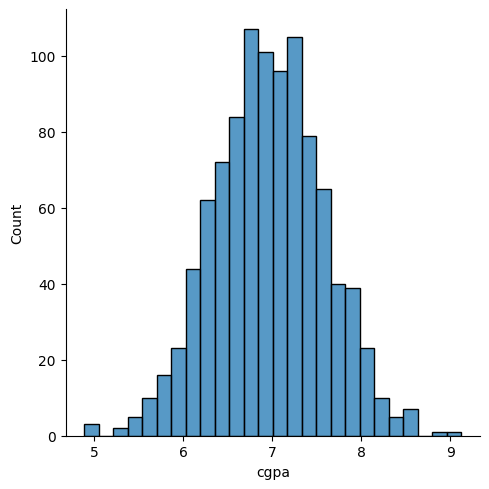

In [ ]:
plt.figure(figsize=(16,5))
sns.displot(df['cgpa'])
plt.show()

so this is normally distributed

In [9]:
print("Mean: ",df['cgpa'].mean())
print("standard deviation: ",df['cgpa'].std())

Mean:  6.96124
standard deviation:  0.6158978751323896


In [11]:
upperLimit = df['cgpa'].mean()+3*df['cgpa'].std()
lowerLimit = df['cgpa'].mean()-3*df['cgpa'].std()
print("Upper Limit: ",upperLimit)
print("Lower Limit: ",lowerLimit)

Upper Limit:  8.808933625397168
Lower Limit:  5.113546374602832


In [16]:
df[(df['cgpa']<lowerLimit) | (df['cgpa']>upperLimit)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


# Trimming

In [17]:
afterTrimming = df[(df['cgpa']<upperLimit) & (df['cgpa']>lowerLimit)]
afterTrimming

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


# set limit using z-score

In [18]:
df['cgpa_zscore'] = (df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()
# xi' = (xi - mean)/std

In [19]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [21]:
df[df['cgpa_zscore']>3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062


In [22]:
df[df['cgpa_zscore']<-3]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [26]:
new_df = df[(df['cgpa_zscore']<3) & (df['cgpa_zscore']>-3)]

In [27]:
new_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371
...,...,...,...,...
991,7.04,57.0,0,0.127878
992,6.26,12.0,0,-1.138565
993,6.73,21.0,1,-0.375452
994,6.48,63.0,0,-0.781363


# Capping

In [28]:
df['cgpa'] = np.where(
    df['cgpa']>upperLimit,
    upperLimit,
    np.where(
        df['cgpa']<lowerLimit,
        lowerLimit,
        df['cgpa']
    )
)

In [29]:
# where work like if condition is true then it will take upper limit value and if condition is false then it will check for next condition and if that is true then it will take lower limit value and if both condition is false then it will take original value of cgpa.
# where(condition, value if true, value if false)